In [28]:
# Cell 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.tokenize import word_tokenize
import nltk

# Download NLTK resources
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ronle\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [29]:
# Cell 2: Load model and data
# Paths
MODEL_PATH = r"C:\Users\ronle\Desktop\BUAS\2024-25c-fai2-adsai-group-group21\data\code\LSTM_300325_1.h5"
TEST_DATA_PATH = r"C:\Users\ronle\Desktop\BUAS\2024-25c-fai2-adsai-group-group21\data\featured\test_gpt.csv"

# Load model
model = load_model(MODEL_PATH)
model.summary()

# Load test data
test_df = pd.read_csv(TEST_DATA_PATH)
print(f"Test data shape: {test_df.shape}")

# Model parameters
MAX_NUM_WORDS = 30000
MAX_SEQUENCE_LENGTH = 100

# Emotion names
emotion_names = {
    0: 'happiness', 1: 'sadness', 2: 'anger', 3: 'fear', 
    4: 'surprise', 5: 'disgust', 6: 'neutral'
}

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text_input (InputLayer)        [(None, 100)]        0           []                               
                                                                                                  
 embedding (Embedding)          (None, 100, 300)     2755800     ['text_input[0][0]']             
                                                                                                  
 spatial_dropout1d (SpatialDrop  (None, 100, 300)    0           ['embedding[0][0]']              
 out1D)                                                                                           
                                                                                                  
 numerical_input (InputLayer)   [(None, 8)]          0           []                           

In [30]:
# Cell 3: Prepare test data
# Get cleaned text
test_texts = test_df['cleaned_text'].values

# Tokenize text
tokenized_texts = []
for text in test_texts:
    if isinstance(text, str):
        tokens = word_tokenize(text.lower())
        tokenized_texts.append(tokens)
    else:
        tokenized_texts.append([])

# Create tokenizer
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)
tokenizer.fit_on_texts([' '.join(tokens) for tokens in tokenized_texts])

# Get sequences
text_sequences = tokenizer.texts_to_sequences([' '.join(tokens) for tokens in tokenized_texts])
X_test_text = pad_sequences(text_sequences, maxlen=MAX_SEQUENCE_LENGTH)

# Get numerical features
numerical_features = [
    'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound', 'vader_intensity',
    'textblob_polarity', 'textblob_subjectivity', 'textblob_polarity_intensity'
]

# Standardize numerical features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_numerical = scaler.fit_transform(test_df[numerical_features].values)

print(f"Shape of text data: {X_test_text.shape}")
print(f"Shape of numerical data: {X_test_numerical.shape}")

Shape of text data: (860, 100)
Shape of numerical data: (860, 8)


In [31]:
# Cell 4: Select examples for analysis
# Select 3 examples from each emotion
selected_examples = []

for emotion_code in range(7):
    # Get indices for this emotion
    indices = test_df[test_df['emotion_code'] == emotion_code].index.tolist()
    
    # Select up to 3 examples
    count = min(3, len(indices))
    for i in range(count):
        idx = indices[i]
        selected_examples.append({
            'index': idx,
            'text': test_df.loc[idx, 'cleaned_text'],
            'emotion_code': emotion_code,
            'emotion_name': emotion_names[emotion_code]
        })

print(f"Selected {len(selected_examples)} examples for analysis")

Selected 17 examples for analysis


Analyzing: hang on to your seats because asia s next top model is back with a vengeance
True emotion: happiness
Predicted emotion: neutral with confidence 0.45
Analyzing importance of 16 tokens


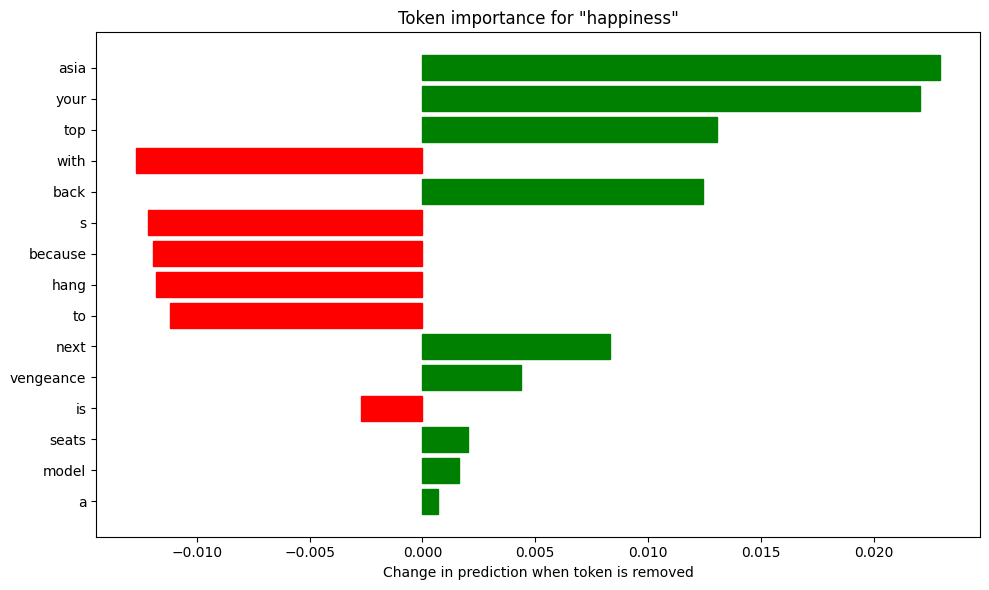

In [32]:
# Cell 5: Analyze first example
# Get first example
example = selected_examples[0]
idx = example['index']
emotion_code = example['emotion_code']
emotion_name = example['emotion_name']
text = example['text']

print(f"Analyzing: {text}")
print(f"True emotion: {emotion_name}")

# Get text and numerical inputs
text_input = X_test_text[idx:idx+1]
numerical_input = X_test_numerical[idx:idx+1]

# Get original prediction
original_prediction = model.predict([text_input, numerical_input], verbose=0)
original_score = original_prediction[0][emotion_code]
predicted_class = np.argmax(original_prediction[0])
confidence = original_prediction[0][predicted_class]

print(f"Predicted emotion: {emotion_names[predicted_class]} with confidence {confidence:.2f}")

# Get reverse word index to convert IDs back to words
reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}

# Get non-padding tokens
non_padding_indices = []
words = []
for i, token_id in enumerate(text_input[0]):
    if token_id != 0:
        non_padding_indices.append(i)
        words.append(reverse_word_index.get(token_id, '?'))

print(f"Analyzing importance of {len(words)} tokens")

# Calculate token importance
importance_values = []
for i in non_padding_indices:
    # Make a copy and zero out a token
    modified_input = np.copy(text_input)
    modified_input[0, i] = 0
    
    # Get new prediction
    new_prediction = model.predict([modified_input, numerical_input], verbose=0)
    new_score = new_prediction[0][emotion_code]
    
    # Importance = change in prediction
    importance = original_score - new_score
    importance_values.append(importance)

# Create word-importance pairs
word_importance_pairs = list(zip(words, importance_values))

# Sort by absolute importance
word_importance_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

# Get top words and importance values
top_words = [word for word, _ in word_importance_pairs[:15]]
top_importance = [imp for _, imp in word_importance_pairs[:15]]

# Plot token importance
plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(top_words)), top_importance)

# Color bars based on value
for i, value in enumerate(top_importance):
    if value < 0:
        bars[i].set_color('r')
    else:
        bars[i].set_color('g')

plt.yticks(range(len(top_words)), top_words)
plt.gca().invert_yaxis()
plt.xlabel('Change in prediction when token is removed')
plt.title(f'Token importance for "{emotion_name}"')
plt.tight_layout()
plt.show()

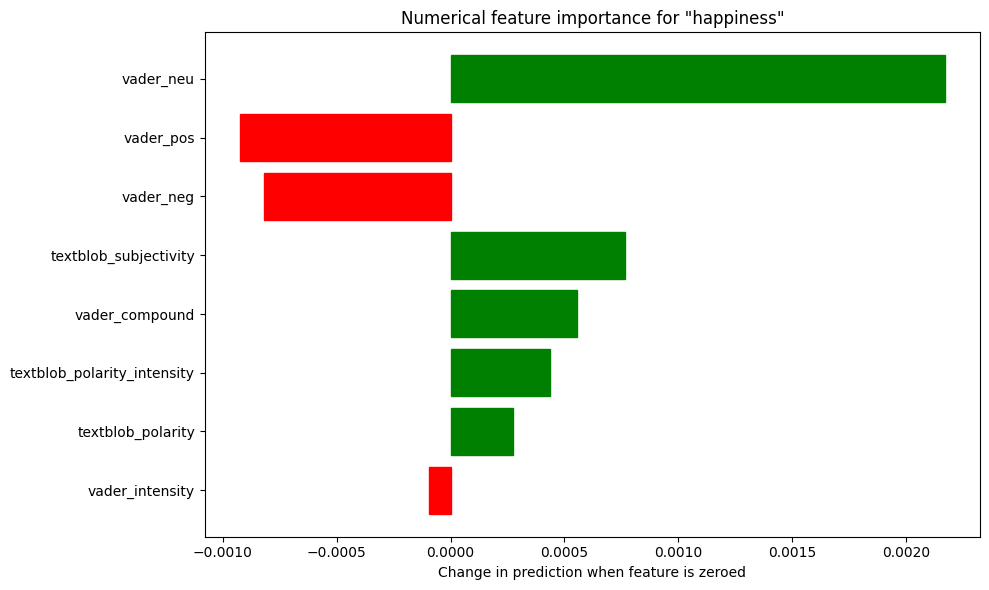

In [33]:
# Cell 6: Analyze numerical features for first example
# Calculate importance for numerical features
numerical_importance = []

for i, feature in enumerate(numerical_features):
    # Make a copy and zero out a feature
    modified_input = np.copy(numerical_input)
    modified_input[0, i] = 0
    
    # Get new prediction
    new_prediction = model.predict([text_input, modified_input], verbose=0)
    new_score = new_prediction[0][emotion_code]
    
    # Importance = change in prediction
    importance = original_score - new_score
    numerical_importance.append(importance)

# Create feature-importance pairs
feature_importance_pairs = list(zip(numerical_features, numerical_importance))

# Sort by absolute importance
feature_importance_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

# Get features and importance values
sorted_features = [f for f, _ in feature_importance_pairs]
sorted_importance = [i for _, i in feature_importance_pairs]

# Plot feature importance
plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(sorted_features)), sorted_importance)

# Color bars based on value
for i, value in enumerate(sorted_importance):
    if value < 0:
        bars[i].set_color('r')
    else:
        bars[i].set_color('g')

plt.yticks(range(len(sorted_features)), sorted_features)
plt.gca().invert_yaxis()
plt.xlabel('Change in prediction when feature is zeroed')
plt.title(f'Numerical feature importance for "{emotion_name}"')
plt.tight_layout()
plt.show()


Example 1 - happiness:
Text: hang on to your seats because asia s next top model is back with a vengeance
Predicted: neutral


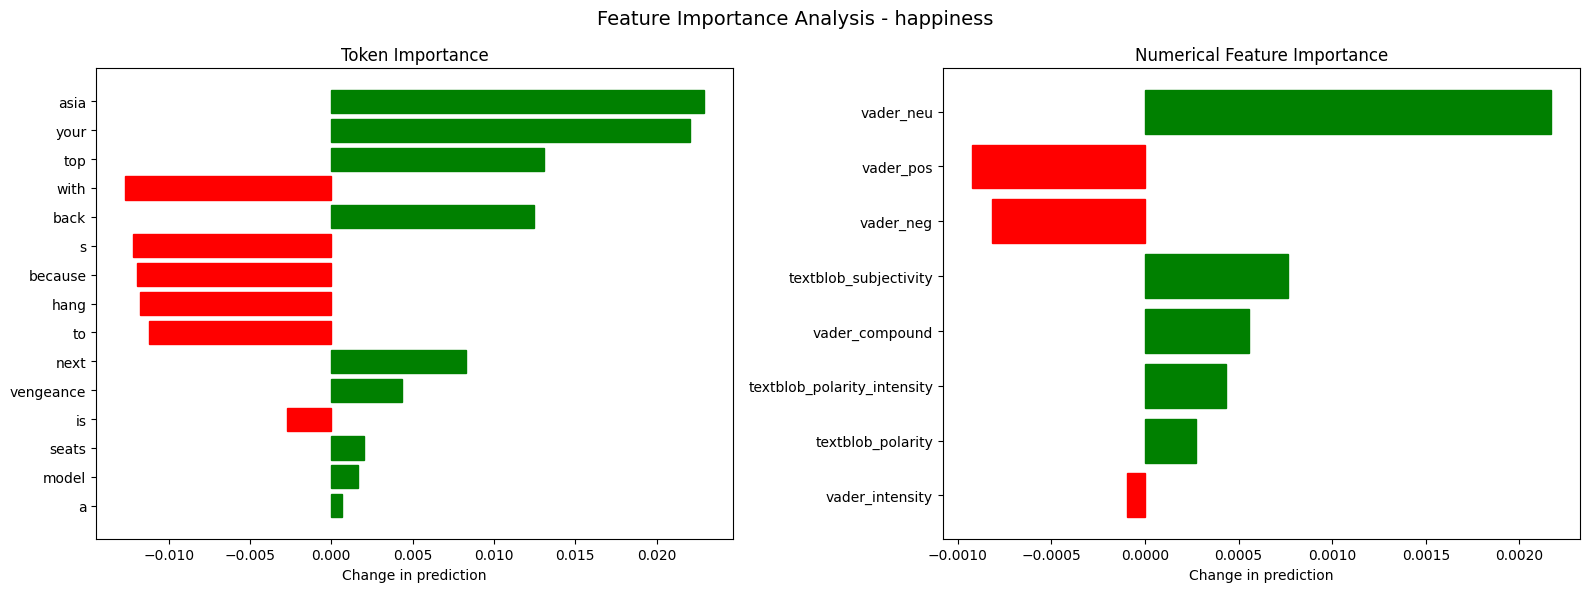


Example 2 - happiness:
Text: prepare for an adventure of a lifetime
Predicted: anger


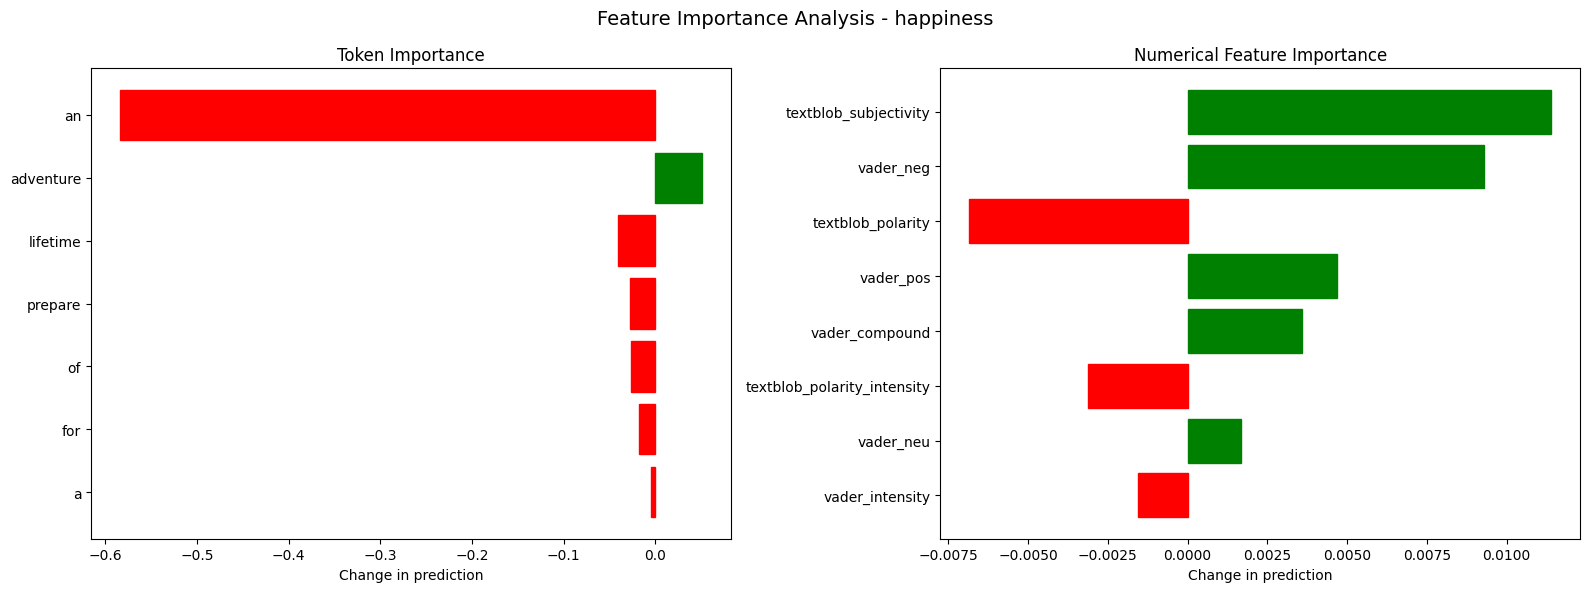


Example 3 - happiness:
Text: all i can say girls for this fierce fifth season is be prepared to expect the unexpected
Predicted: surprise


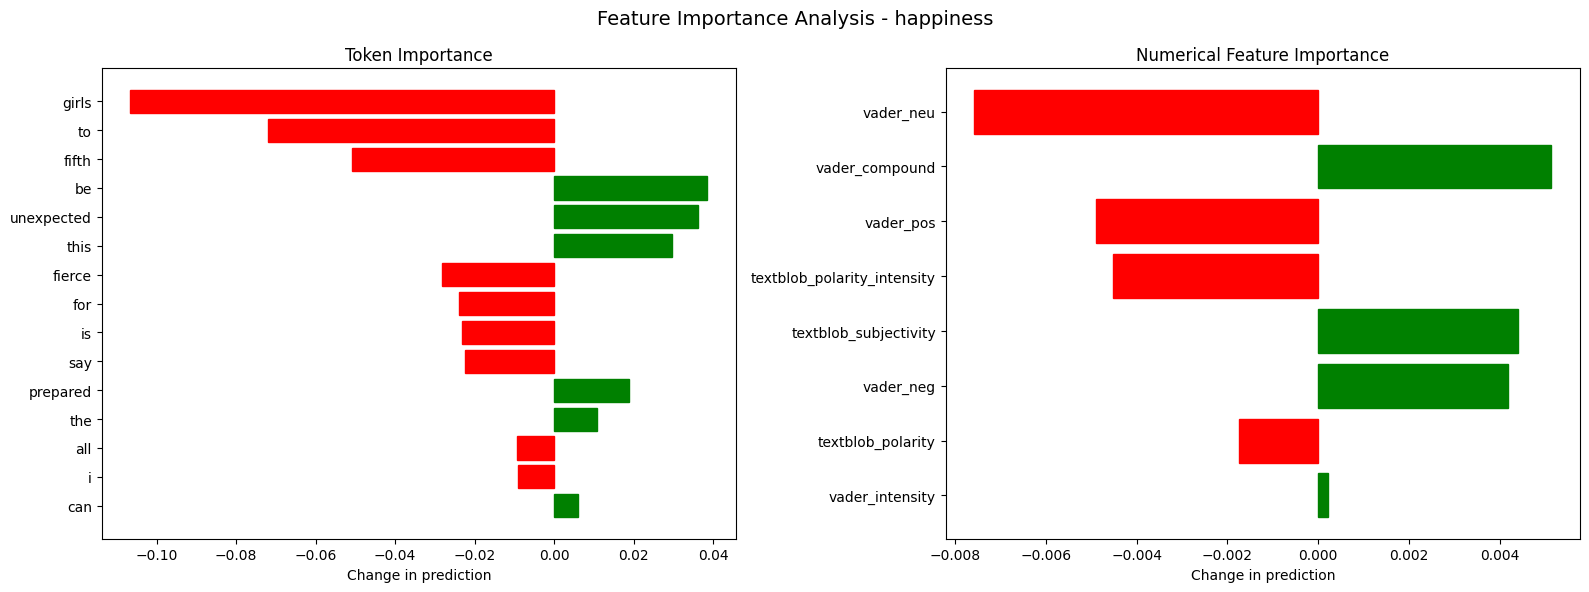


Example 4 - sadness:
Text: congratulations clara why are you crying
Predicted: sadness


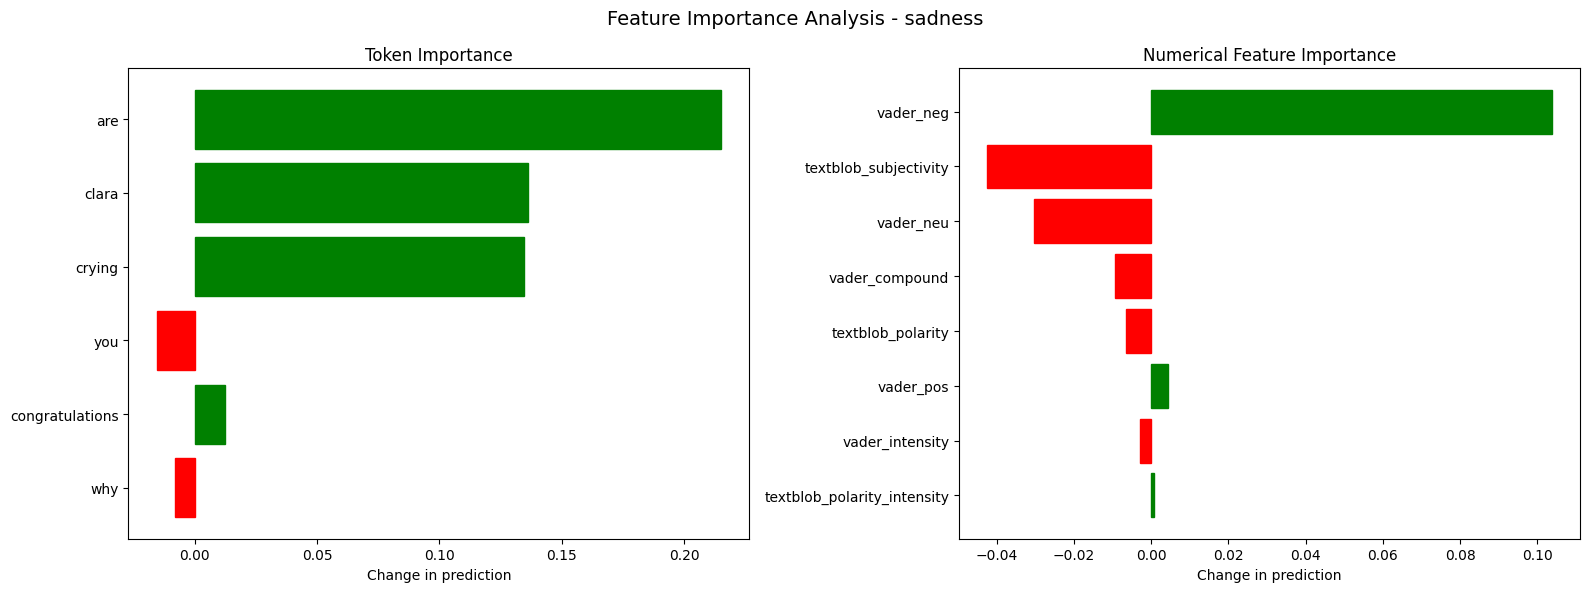


Example 5 - sadness:
Text: so even though i am the first girl to get eliminated i
Predicted: neutral


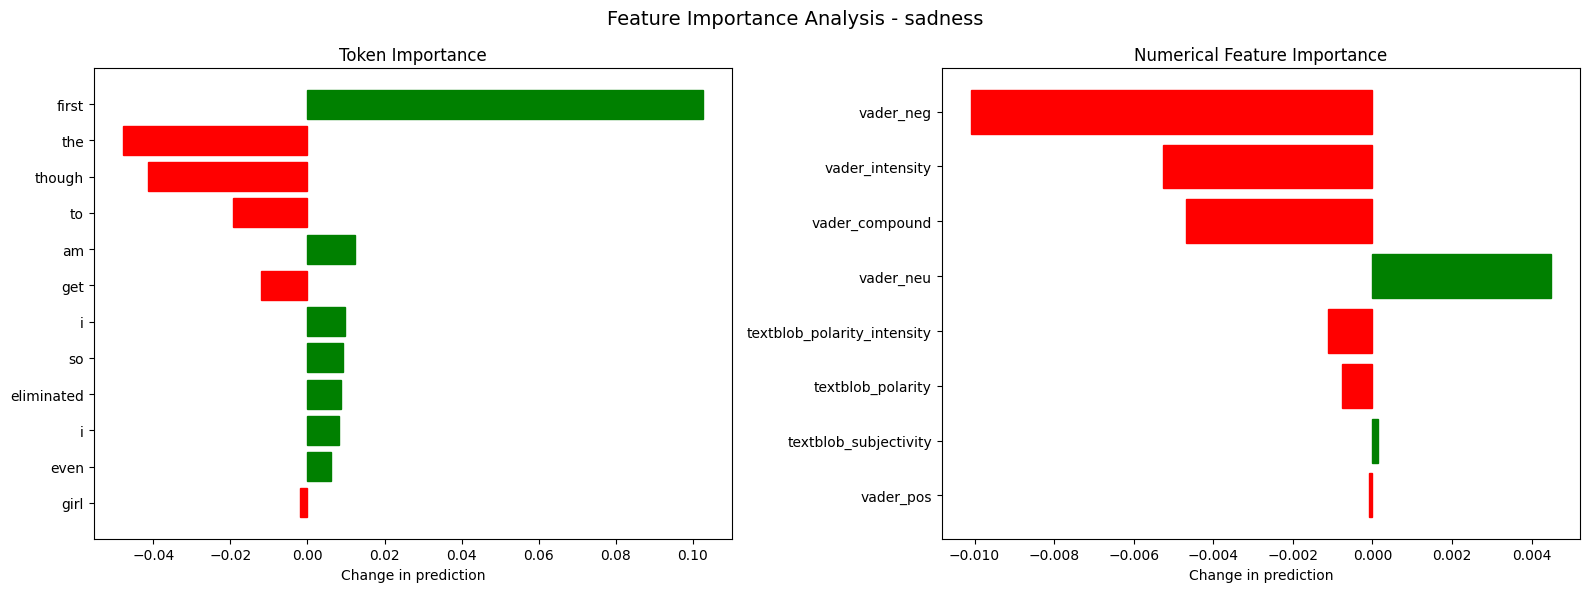


Example 6 - anger:
Text: it is making you look very angry
Predicted: neutral


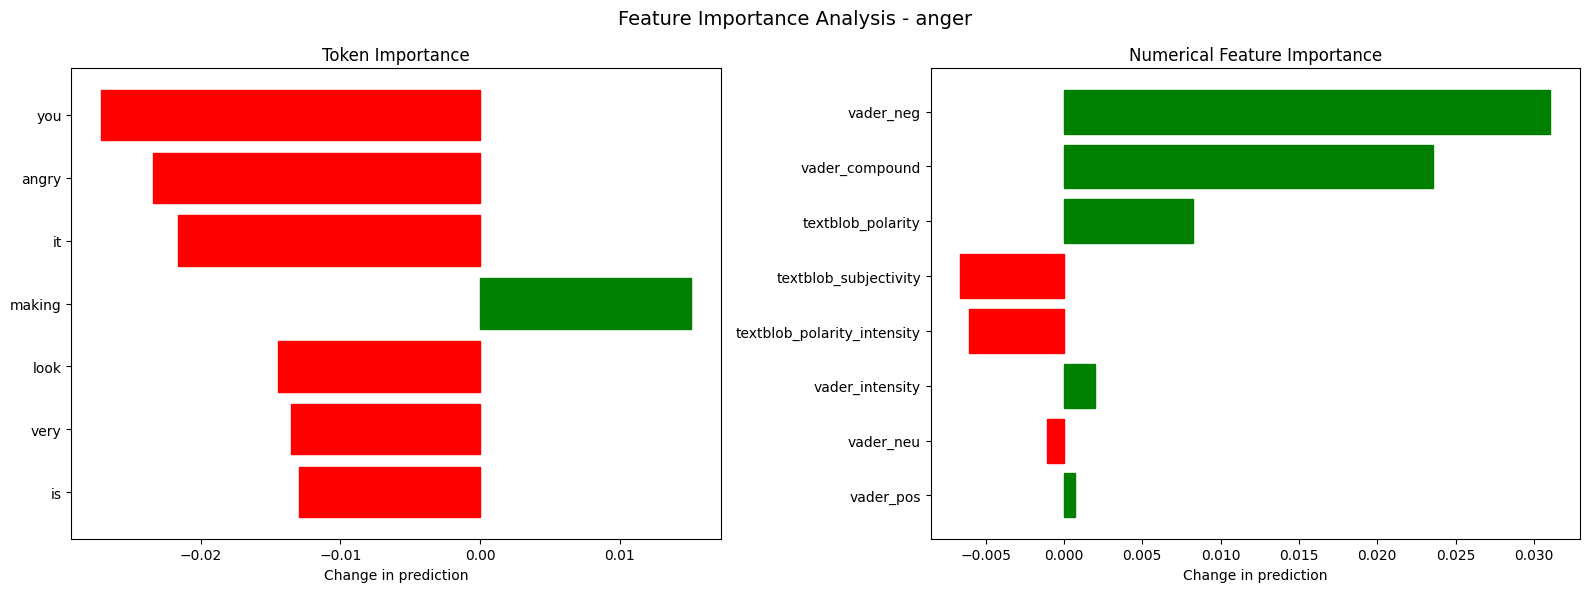


Example 7 - anger:
Text: that s angry
Predicted: surprise


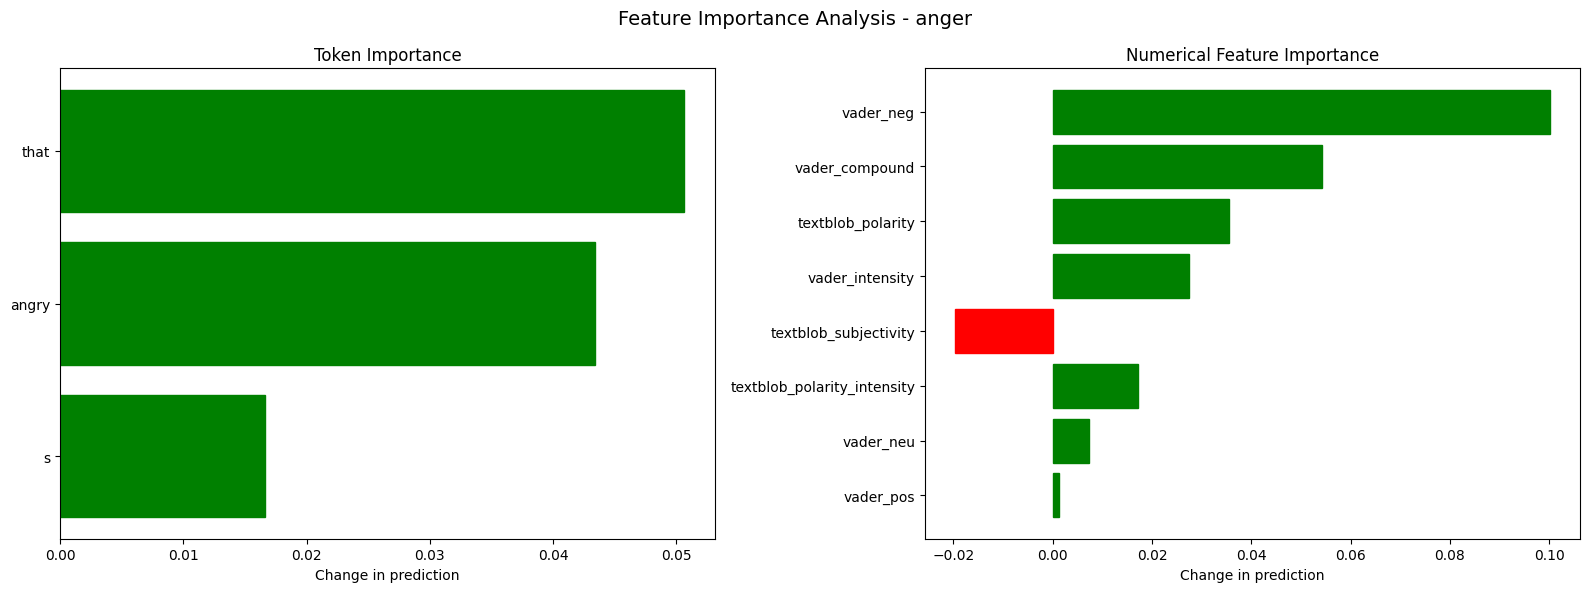


Example 8 - anger:
Text: more angry
Predicted: neutral


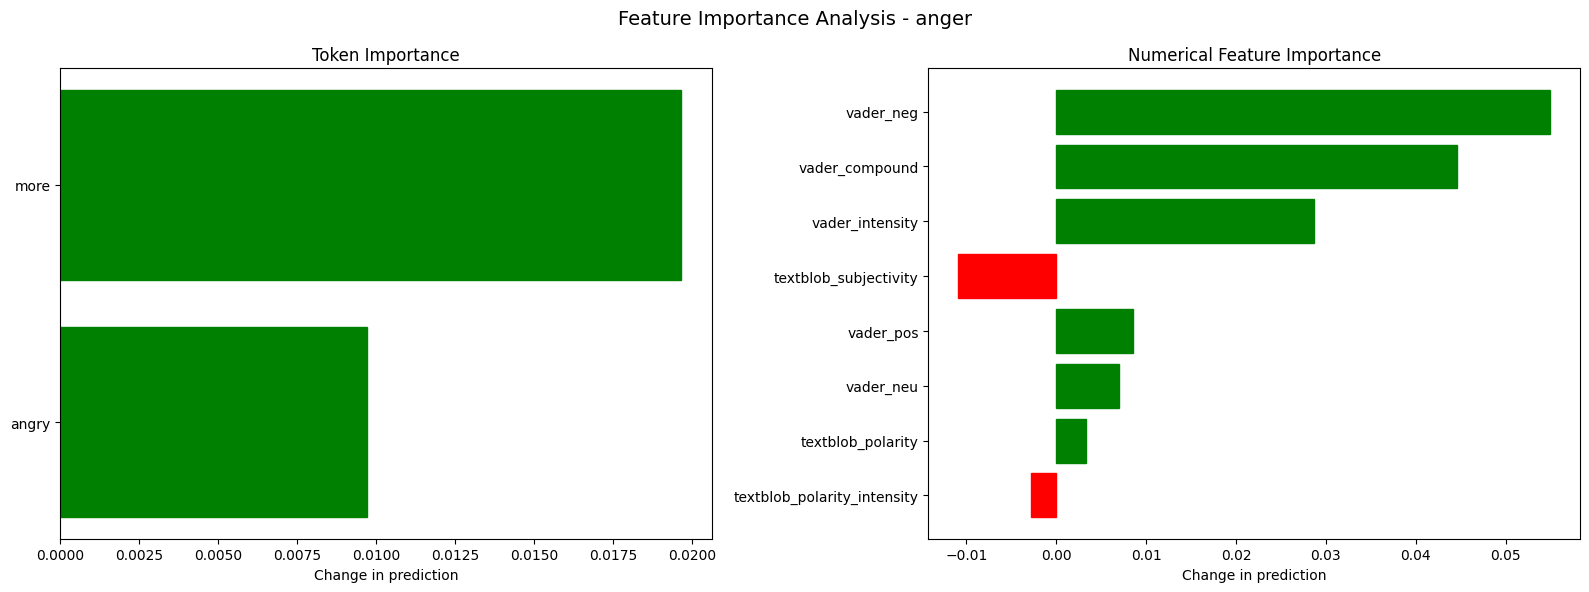


Example 9 - fear:
Text: at this moment i am feeling like my stomach is up to my chest like so nervous oh my god it is actually happening right now
Predicted: neutral


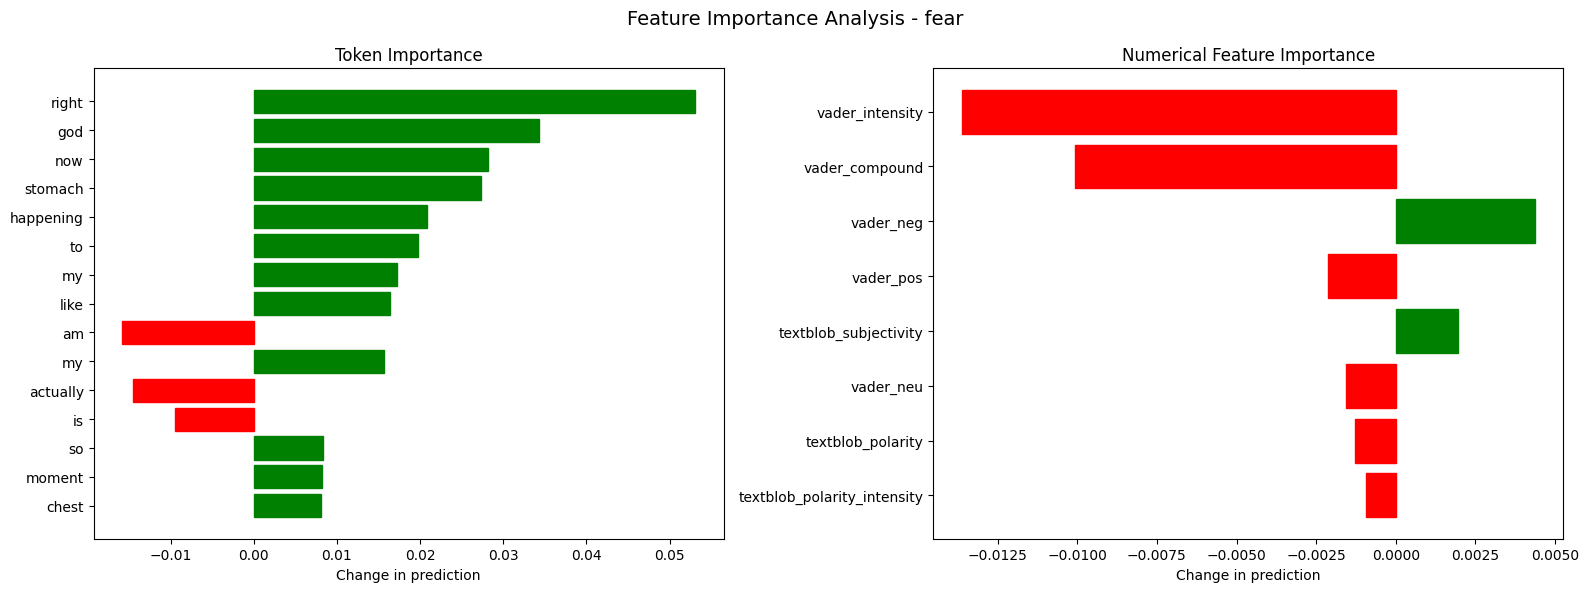


Example 10 - fear:
Text: all right i am scared i ve never actually been on the runway so it is very nerve wracking for me
Predicted: anger


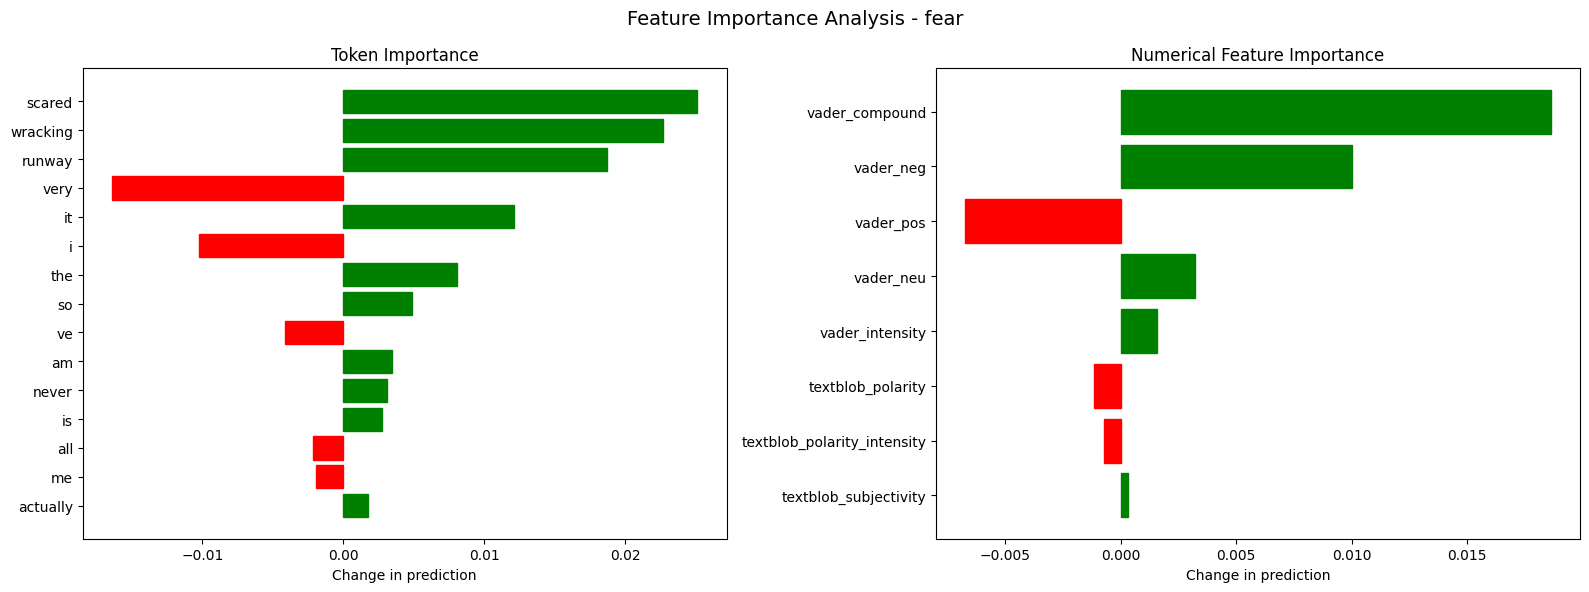


Example 11 - fear:
Text: so i am very excited but i was so scared also
Predicted: fear


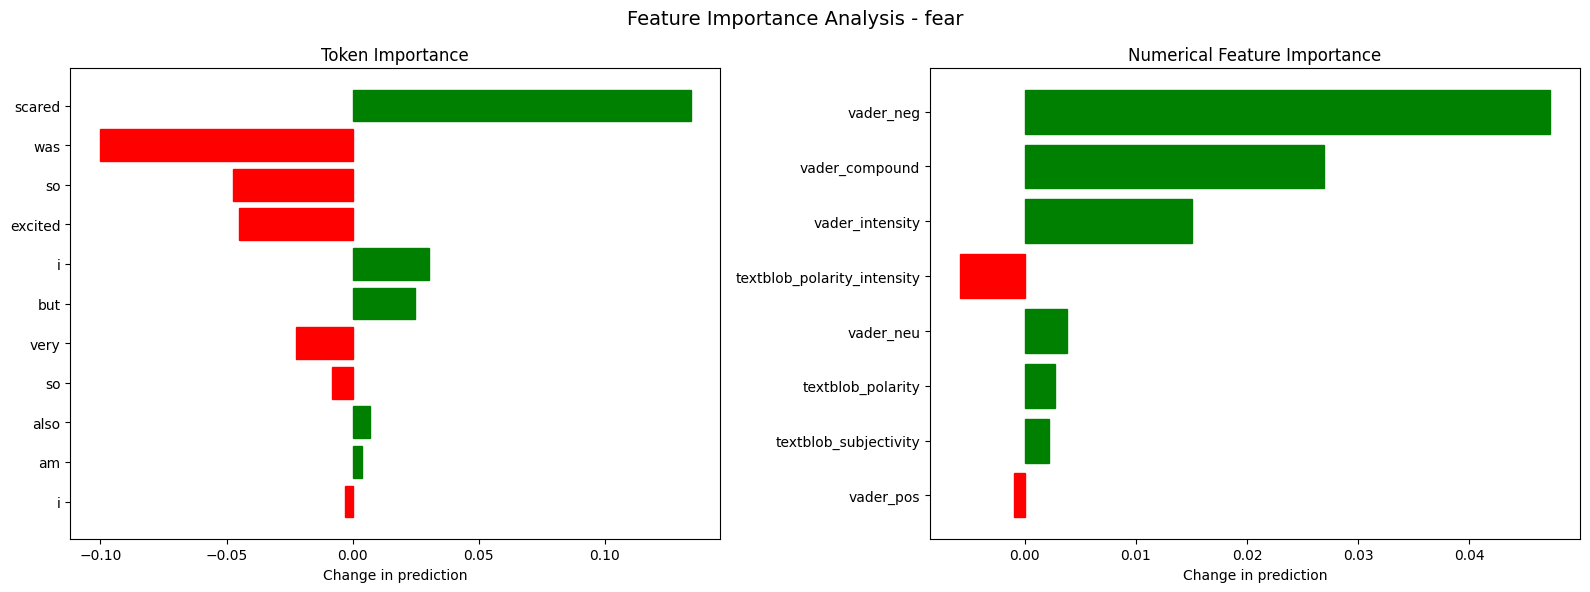


Example 12 - surprise:
Text: wow cara is so beautiful she is tall and she is so poised
Predicted: neutral


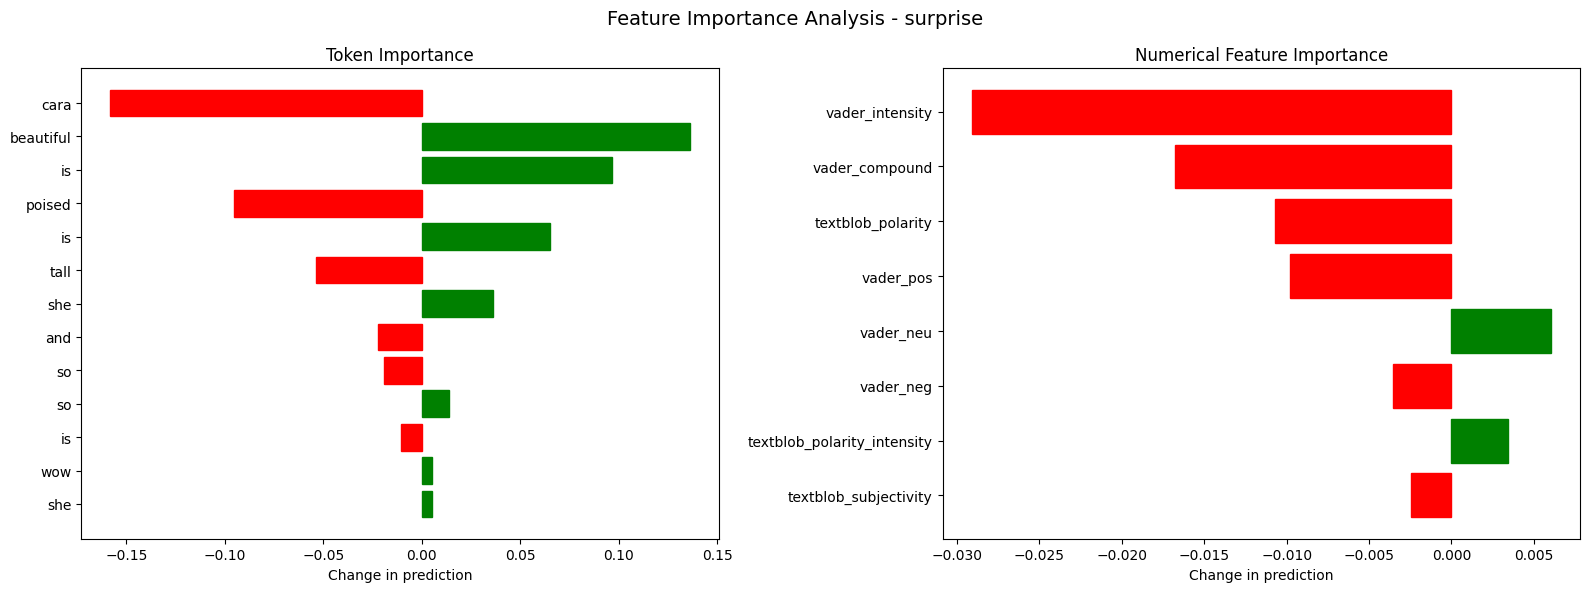


Example 13 - surprise:
Text: then when you hit the end of the runway you will get another surprise
Predicted: anger


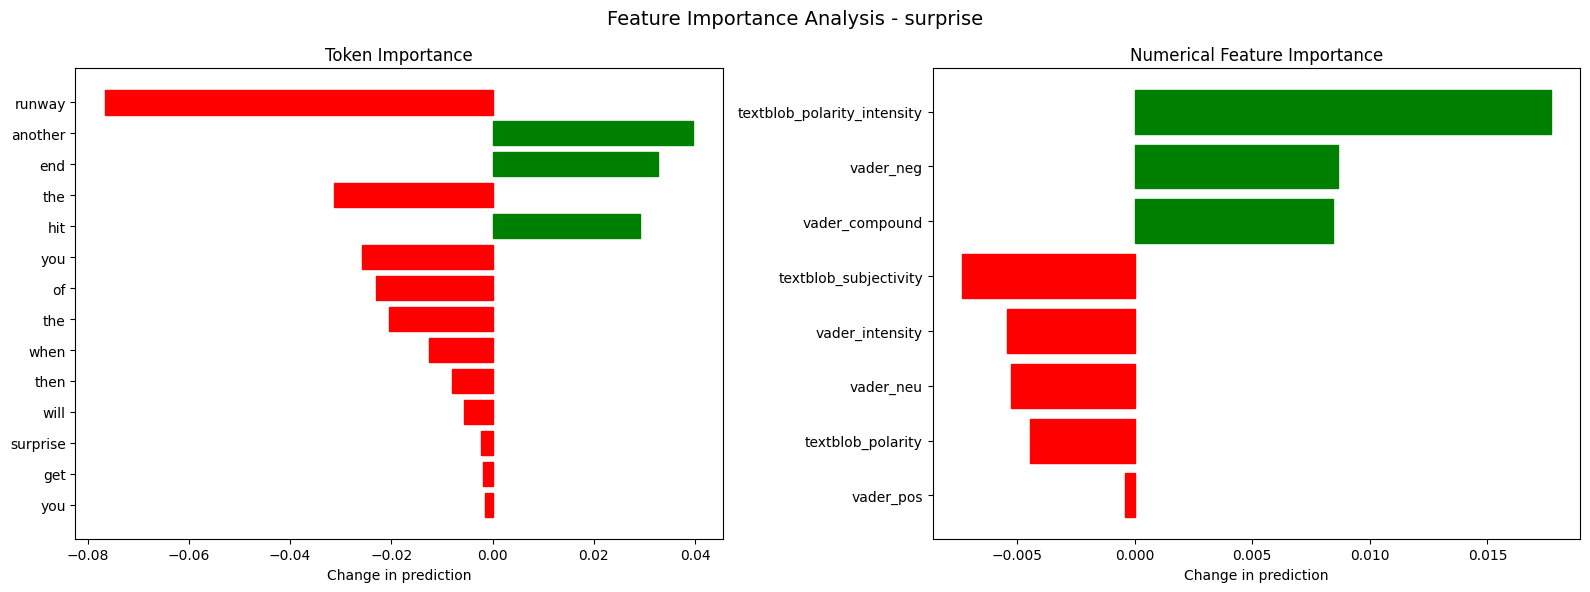


Example 14 - surprise:
Text: pleasantly surprised valerie
Predicted: neutral


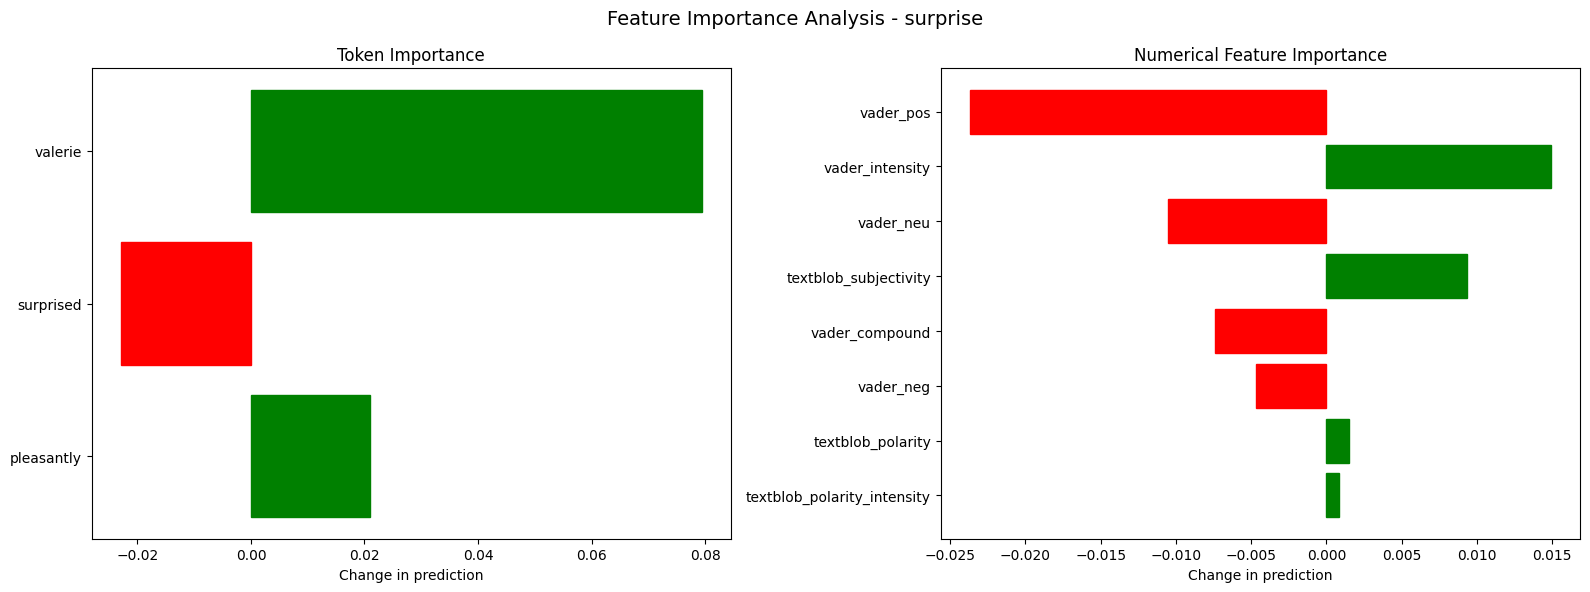


Example 15 - neutral:
Text: thousands of model hopefuls from all over asia jumped at the chance to pursue their supermodel dream
Predicted: neutral


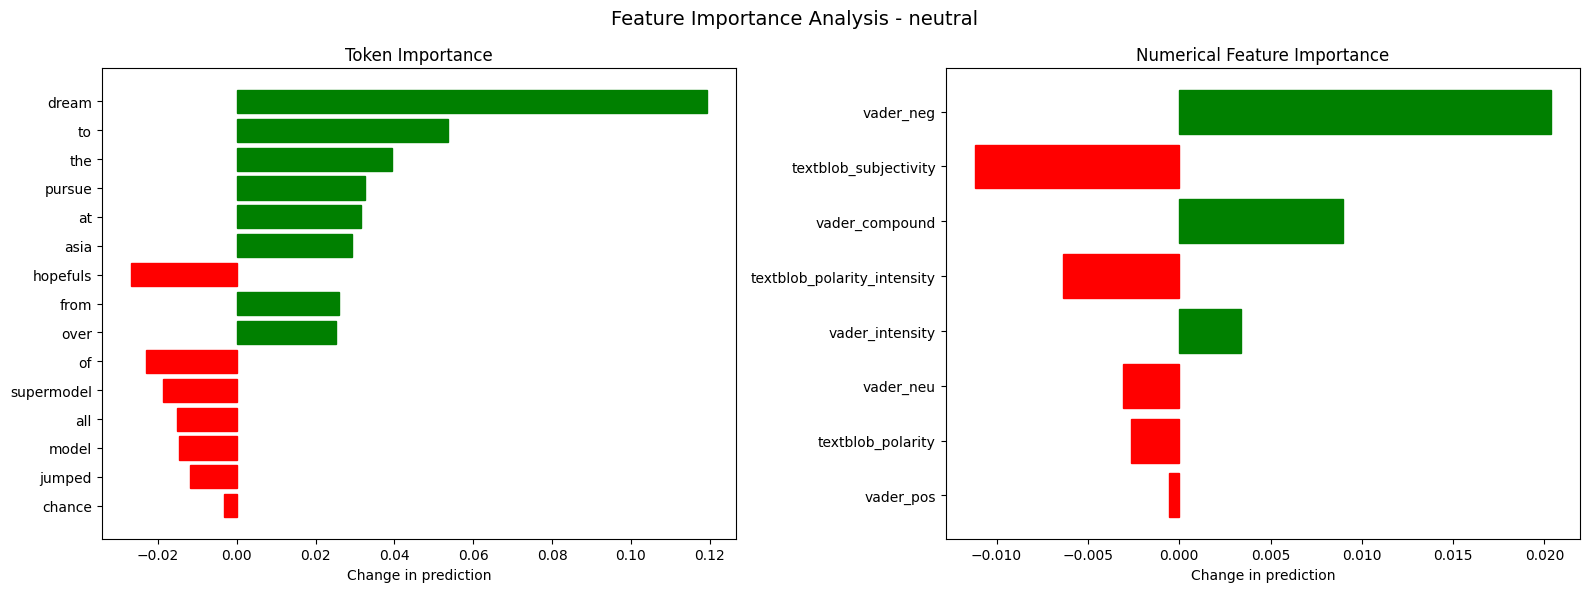


Example 16 - neutral:
Text: but only the standout modeling talent were chosen as our final 14
Predicted: surprise


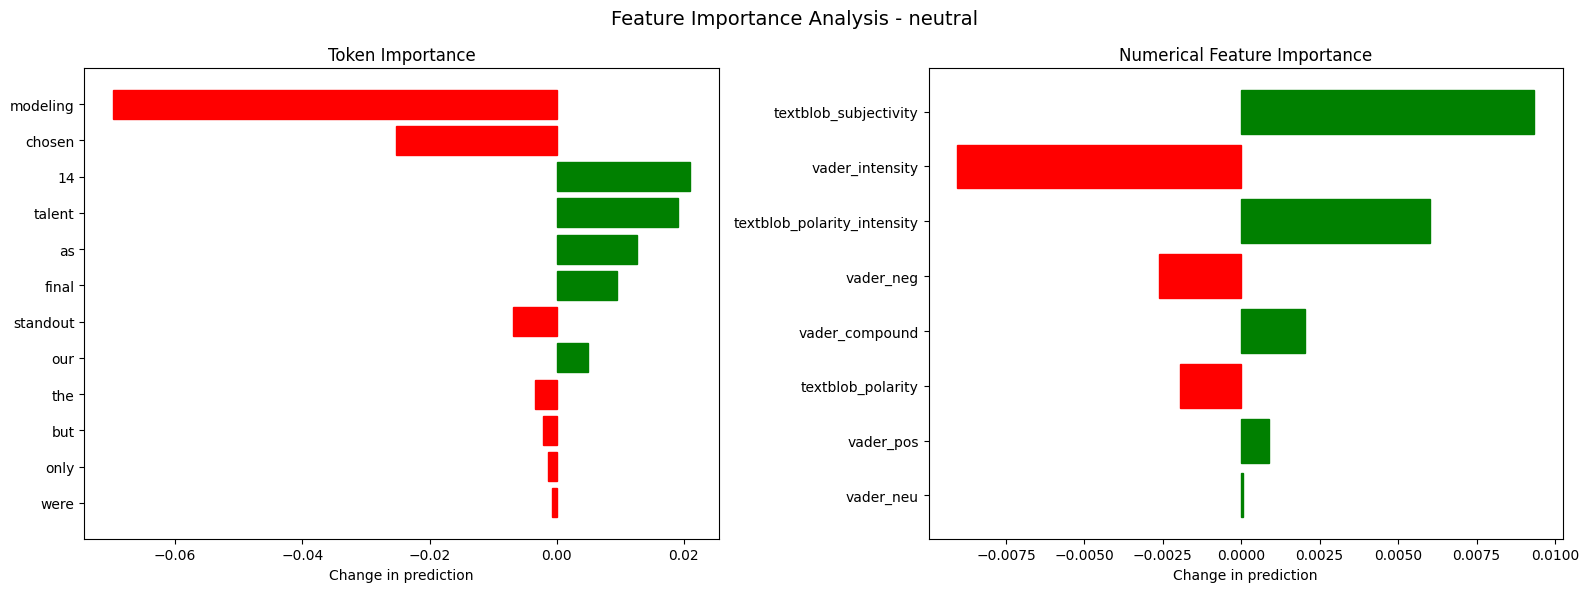


Example 17 - neutral:
Text: with twists and turns at every corner this is a crazy competition
Predicted: surprise


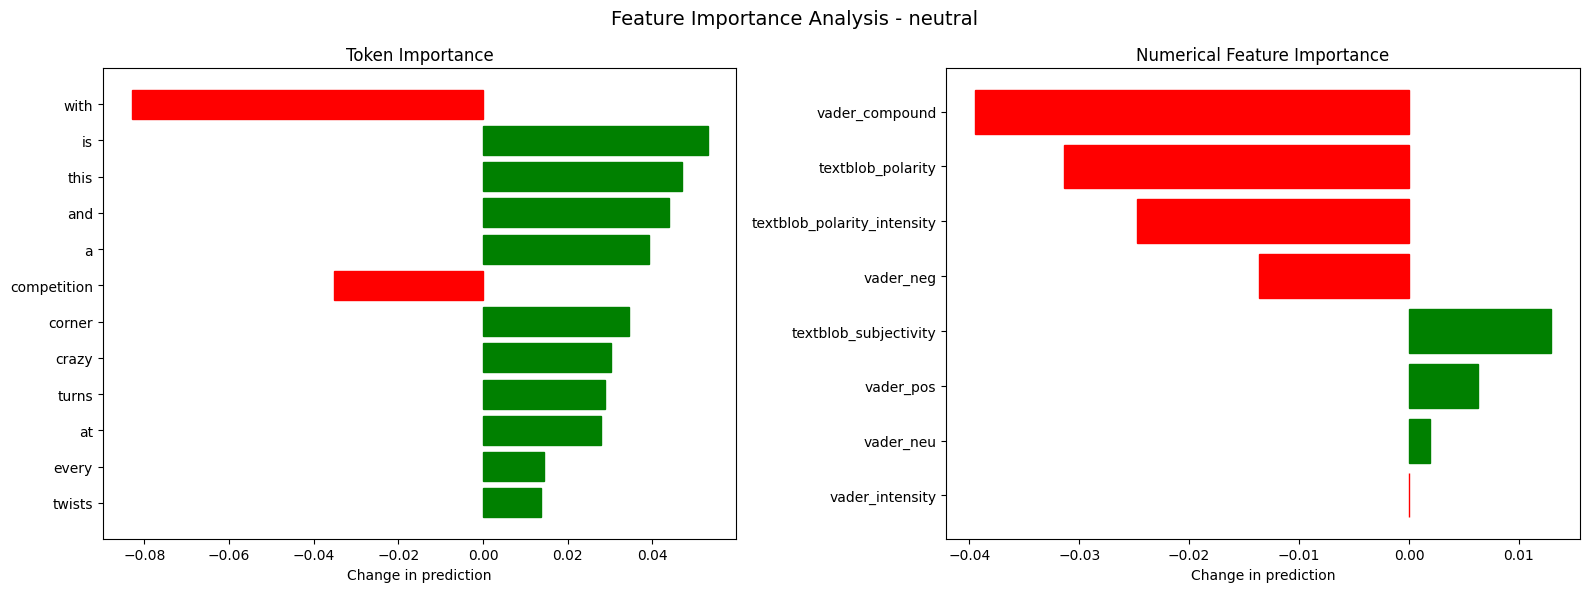

In [39]:
# Cell 7: Process multiple examples
# Loop through first 17 examples to keep output manageable
for example_num in range(min(17, len(selected_examples))):
    example = selected_examples[example_num]
    idx = example['index']
    emotion_code = example['emotion_code']
    emotion_name = example['emotion_name']
    text = example['text']
    
    print(f"\nExample {example_num+1} - {emotion_name}:")
    print(f"Text: {text}")
    
    # Get inputs
    text_input = X_test_text[idx:idx+1]
    numerical_input = X_test_numerical[idx:idx+1]
    
    # Get original prediction
    original_prediction = model.predict([text_input, numerical_input], verbose=0)
    original_score = original_prediction[0][emotion_code]
    predicted_class = np.argmax(original_prediction[0])
    
    print(f"Predicted: {emotion_names[predicted_class]}")
    
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Token importance analysis
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    
    # Get non-padding tokens
    words = []
    token_importance = []
    
    # Process all non-padding tokens
    for i, token_id in enumerate(text_input[0]):
        if token_id != 0:
            word = reverse_word_index.get(token_id, '?')
            
            # Perturb this token
            modified_input = np.copy(text_input)
            modified_input[0, i] = 0
            
            # Get new prediction
            new_prediction = model.predict([modified_input, numerical_input], verbose=0)
            new_score = new_prediction[0][emotion_code]
            
            # Importance = change in prediction
            importance = original_score - new_score
            
            words.append(word)
            token_importance.append(importance)
    
    # Sort by importance
    word_importance = list(zip(words, token_importance))
    word_importance.sort(key=lambda x: abs(x[1]), reverse=True)
    
    # Get top 15 tokens
    top_words = [w for w, _ in word_importance[:15]]
    top_importance = [i for _, i in word_importance[:15]]
    
    # Plot token importance
    bars1 = ax1.barh(range(len(top_words)), top_importance)
    
    # Color bars
    for i, value in enumerate(top_importance):
        if value < 0:
            bars1[i].set_color('r')
        else:
            bars1[i].set_color('g')
    
    ax1.set_yticks(range(len(top_words)))
    ax1.set_yticklabels(top_words)
    ax1.invert_yaxis()
    ax1.set_xlabel('Change in prediction')
    ax1.set_title('Token Importance')
    
    # Feature importance analysis
    feature_importance = []
    
    # Process all numerical features
    for i, feature in enumerate(numerical_features):
        # Perturb this feature
        modified_input = np.copy(numerical_input)
        modified_input[0, i] = 0
        
        # Get new prediction
        new_prediction = model.predict([text_input, modified_input], verbose=0)
        new_score = new_prediction[0][emotion_code]
        
        # Importance = change in prediction
        importance = original_score - new_score
        feature_importance.append(importance)
    
    # Sort by importance
    feature_pairs = list(zip(numerical_features, feature_importance))
    feature_pairs.sort(key=lambda x: abs(x[1]), reverse=True)
    
    sorted_features = [f for f, _ in feature_pairs]
    sorted_importance = [i for _, i in feature_pairs]
    
    # Plot feature importance
    bars2 = ax2.barh(range(len(sorted_features)), sorted_importance)
    
    # Color bars
    for i, value in enumerate(sorted_importance):
        if value < 0:
            bars2[i].set_color('r')
        else:
            bars2[i].set_color('g')
    
    ax2.set_yticks(range(len(sorted_features)))
    ax2.set_yticklabels(sorted_features)
    ax2.invert_yaxis()
    ax2.set_xlabel('Change in prediction')
    ax2.set_title('Numerical Feature Importance')
    
    plt.suptitle(f'Feature Importance Analysis - {emotion_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [35]:
# Cell 8: Analyze importance by emotion
# Create dictionaries to store important tokens/features by emotion
important_tokens = {code: {} for code in range(7)}
important_features = {code: {feature: 0 for feature in numerical_features} for code in range(7)}
emotion_counts = {code: 0 for code in range(7)}

# Process all examples
for example in selected_examples:
    idx = example['index']
    emotion_code = example['emotion_code']
    
    # Track counts
    emotion_counts[emotion_code] += 1
    
    # Get inputs
    text_input = X_test_text[idx:idx+1]
    numerical_input = X_test_numerical[idx:idx+1]
    
    # Get original prediction
    original_prediction = model.predict([text_input, numerical_input], verbose=0)
    original_score = original_prediction[0][emotion_code]
    
    # Get tokens and calculate importance
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    
    for i, token_id in enumerate(text_input[0]):
        if token_id != 0:
            word = reverse_word_index.get(token_id, '?')
            
            # Skip if already processed this word for this emotion
            if word in important_tokens[emotion_code]:
                continue
                
            # Perturb token
            modified_input = np.copy(text_input)
            modified_input[0, i] = 0
            
            # Get new prediction
            new_prediction = model.predict([modified_input, numerical_input], verbose=0)
            new_score = new_prediction[0][emotion_code]
            
            # Store importance
            importance = original_score - new_score
            important_tokens[emotion_code][word] = importance
    
    # Calculate importance for numerical features
    for i, feature in enumerate(numerical_features):
        # Perturb feature
        modified_input = np.copy(numerical_input)
        modified_input[0, i] = 0
        
        # Get new prediction
        new_prediction = model.predict([text_input, modified_input], verbose=0)
        new_score = new_prediction[0][emotion_code]
        
        # Accumulate importance
        importance = original_score - new_score
        important_features[emotion_code][feature] += importance

# Average feature importance
for emotion_code in range(7):
    if emotion_counts[emotion_code] > 0:
        for feature in numerical_features:
            important_features[emotion_code][feature] /= emotion_counts[emotion_code]

# Print top tokens for each emotion
print("Most important tokens by emotion:")
for emotion_code in range(7):
    if emotion_counts[emotion_code] == 0:
        continue
    
    print(f"\n{emotion_names[emotion_code].upper()}:")
    
    # Sort tokens by absolute importance
    sorted_tokens = sorted(important_tokens[emotion_code].items(), 
                          key=lambda x: abs(x[1]), reverse=True)
    
    # Print top 10 tokens
    for word, score in sorted_tokens[:10]:
        print(f"  - {word}: {score:.6f}")

Most important tokens by emotion:

HAPPINESS:
  - an: -0.583917
  - girls: -0.106588
  - fifth: -0.050873
  - adventure: 0.050443
  - lifetime: -0.040269
  - be: 0.038506
  - unexpected: 0.036187
  - this: 0.029725
  - fierce: -0.028159
  - prepare: -0.027373

SADNESS:
  - are: 0.215039
  - clara: 0.136227
  - crying: 0.134385
  - first: 0.102606
  - the: -0.047959
  - though: -0.041412
  - to: -0.019361
  - you: -0.015511
  - congratulations: 0.012530
  - am: 0.012291

ANGER:
  - that: 0.050613
  - you: -0.027134
  - angry: -0.023425
  - it: -0.021636
  - more: 0.019646
  - s: 0.016625
  - making: 0.015106
  - look: -0.014454
  - very: -0.013557
  - is: -0.012982

FEAR:
  - was: -0.100210
  - right: 0.053046
  - excited: -0.045240
  - god: 0.034279
  - now: 0.028188
  - stomach: 0.027384
  - scared: 0.025106
  - but: 0.024821
  - wracking: 0.022663
  - happening: 0.020810

SURPRISE:
  - cara: -0.158145
  - beautiful: 0.136129
  - is: 0.096366
  - poised: -0.095312
  - valerie: 0.07944

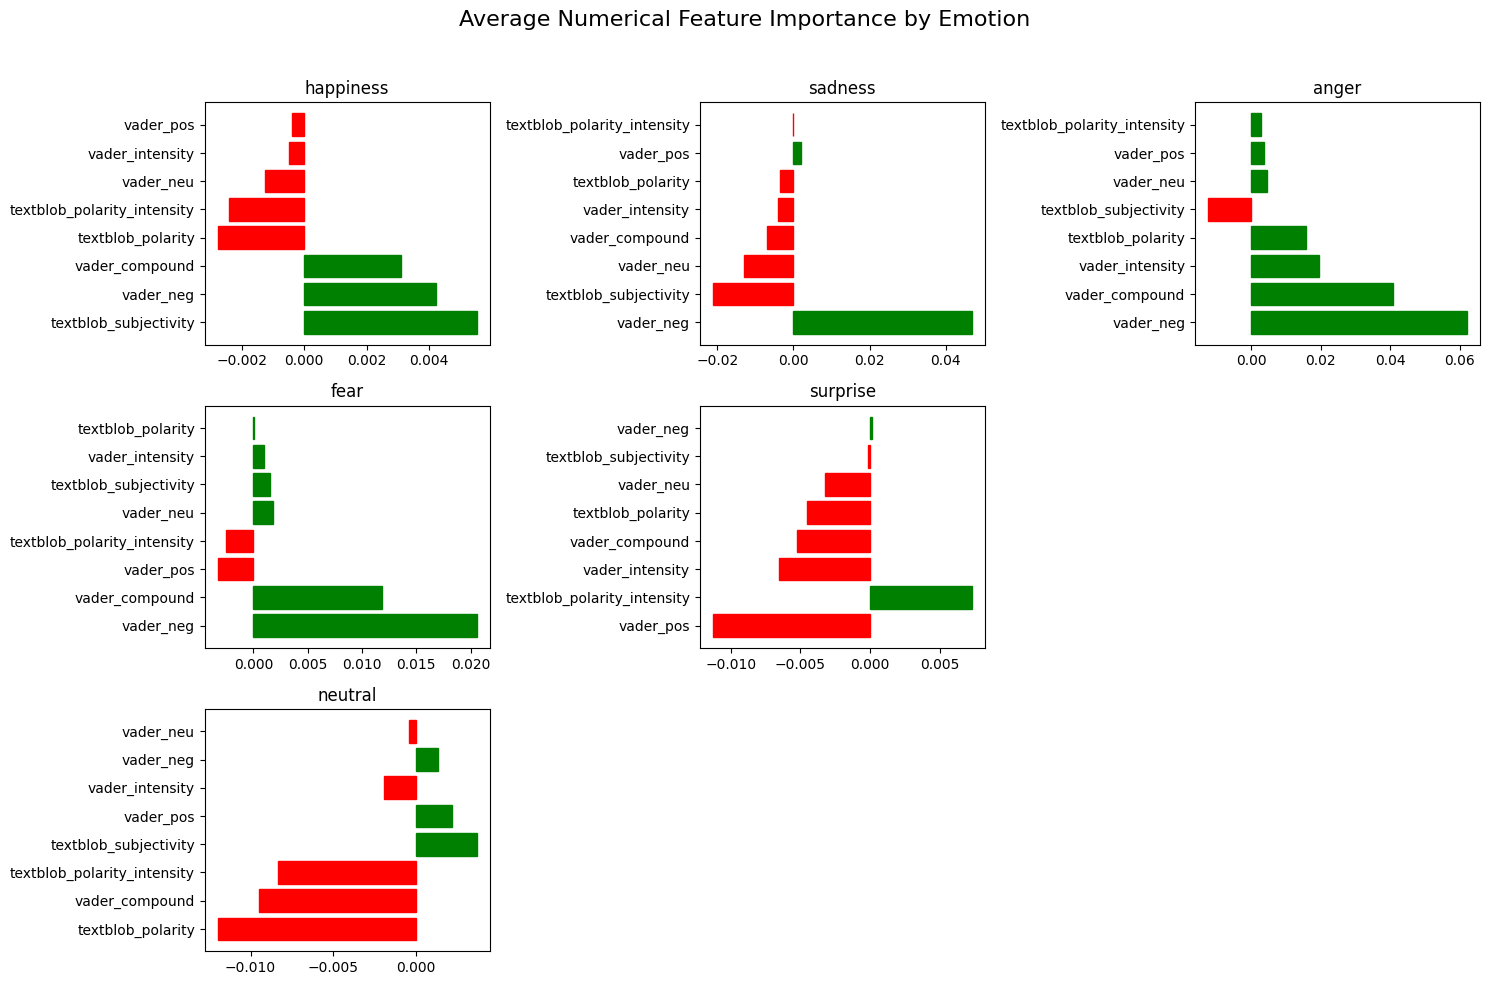


Most important numerical features by emotion:

HAPPINESS:
  - textblob_subjectivity: 0.005521
  - vader_neg: 0.004217
  - vader_compound: 0.003096

SADNESS:
  - vader_neg: 0.046824
  - textblob_subjectivity: -0.021149
  - vader_neu: -0.012880

ANGER:
  - vader_neg: 0.062070
  - vader_compound: 0.040766
  - vader_intensity: 0.019340

FEAR:
  - vader_neg: 0.020567
  - vader_compound: 0.011837
  - vader_pos: -0.003297

SURPRISE:
  - vader_pos: -0.011288
  - textblob_polarity_intensity: 0.007315
  - vader_intensity: -0.006540

NEUTRAL:
  - textblob_polarity: -0.011989
  - vader_compound: -0.009498
  - textblob_polarity_intensity: -0.008365


In [36]:
# Cell 9: Visualize numerical feature importance by emotion
# Plot feature importance for each emotion
plt.figure(figsize=(15, 10))

for i, emotion_code in enumerate(range(7)):
    if emotion_counts[emotion_code] == 0:
        continue
    
    # Get feature importance for this emotion
    importance_dict = important_features[emotion_code]
    
    # Sort by absolute importance
    sorted_features = sorted(importance_dict.items(), 
                            key=lambda x: abs(x[1]), reverse=True)
    
    features = [item[0] for item in sorted_features]
    values = [item[1] for item in sorted_features]
    
    # Create subplot
    plt.subplot(3, 3, i + 1)
    bars = plt.barh(features, values)
    
    # Color bars
    for j, value in enumerate(values):
        if value < 0:
            bars[j].set_color('r')
        else:
            bars[j].set_color('g')
    
    plt.title(f"{emotion_names[emotion_code]}")
    plt.tight_layout()

plt.suptitle("Average Numerical Feature Importance by Emotion", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Print top numerical features for each emotion
print("\nMost important numerical features by emotion:")
for emotion_code in range(7):
    if emotion_counts[emotion_code] == 0:
        continue
    
    print(f"\n{emotion_names[emotion_code].upper()}:")
    
    # Sort features by absolute importance
    sorted_features = sorted(important_features[emotion_code].items(), 
                            key=lambda x: abs(x[1]), reverse=True)
    
    # Print top 3 features
    for feature, score in sorted_features[:3]:
        print(f"  - {feature}: {score:.6f}")

In [38]:
# Cell 10: Analysis and conclusions
# Compare predictions with important tokens
for i, example in enumerate(selected_examples[:17]):
    idx = example['index']
    emotion_code = example['emotion_code']
    emotion_name = example['emotion_name']
    text = example['text']
    
    # Get inputs
    text_input = X_test_text[idx:idx+1]
    numerical_input = X_test_numerical[idx:idx+1]
    
    # Get prediction
    prediction = model.predict([text_input, numerical_input], verbose=0)
    predicted_class = np.argmax(prediction[0])
    
    print(f"\nExample {i+1}:")
    print(f"Text: {text}")
    print(f"True emotion: {emotion_name}")
    print(f"Predicted emotion: {emotion_names[predicted_class]}")
    
    # Get token importance
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    original_score = prediction[0][emotion_code]
    
    word_scores = []
    
    for j, token_id in enumerate(text_input[0]):
        if token_id != 0:
            word = reverse_word_index.get(token_id, '?')
            
            # Perturb token
            modified_input = np.copy(text_input)
            modified_input[0, j] = 0
            
            # Get new prediction
            new_prediction = model.predict([modified_input, numerical_input], verbose=0)
            new_score = new_prediction[0][emotion_code]
            
            # Store importance
            importance = original_score - new_score
            word_scores.append((word, importance))
    
    # Sort and print top 5 important tokens
    word_scores.sort(key=lambda x: abs(x[1]), reverse=True)
    print("Most important tokens:")
    for word, score in word_scores[:5]:
        print(f"  - {word}: {score:.6f}")
    
    print("\n" + "-"*50)


Example 1:
Text: hang on to your seats because asia s next top model is back with a vengeance
True emotion: happiness
Predicted emotion: neutral
Most important tokens:
  - asia: 0.022934
  - your: 0.022053
  - top: 0.013058
  - with: -0.012679
  - back: 0.012441

--------------------------------------------------

Example 2:
Text: prepare for an adventure of a lifetime
True emotion: happiness
Predicted emotion: anger
Most important tokens:
  - an: -0.583917
  - adventure: 0.050443
  - lifetime: -0.040269
  - prepare: -0.027373
  - of: -0.026552

--------------------------------------------------

Example 3:
Text: all i can say girls for this fierce fifth season is be prepared to expect the unexpected
True emotion: happiness
Predicted emotion: surprise
Most important tokens:
  - girls: -0.106588
  - to: -0.071910
  - fifth: -0.050873
  - be: 0.038506
  - unexpected: 0.036187

--------------------------------------------------

Example 4:
Text: congratulations clara why are you crying
T